In [1]:
# Parameters
BATCH_MODE = "true"


# PyMC-11 : Modèles de Sujets (Topic Models) et LDA

**Navigation** : [Index](../README.md) | [<< PyMC-10](PyMC-10-Model-Selection.ipynb) | [PyMC-12 >>](PyMC-12-Modeles-Hierarchiques.ipynb)

**Equivalent Infer.NET** : [Infer-11-Topic-Models](../Infer/Infer-11-Topic-Models.ipynb)


**Duree estimee** : 55 minutes
**Objectifs** :
- Comprendre le modèle generatif LDA (Latent Dirichlet Allocation)
- Implementer un modèle de sujets simplifie avec PyMC
- Observer le problème de symetrie et le resoudre avec des priors asymetriques
- Visualiser les distributions de mots par sujet
- Comparer Infer.NET VMP vs PyMC NUTS pour les modèles discrets

**Prerequis** : PyMC-1 a PyMC-10, algebre lineaire (matrices, vecteurs)


In [2]:
import warnings
# arviz (FutureWarning de refactor) et pytensor ("could not link BLAS", advisory de perf, pas de correctness)
# leakent le chemin absolu du fichier source site-packages ; on les filtre. Les alertes utiles (R-hat, ESS) restent visibles.
warnings.filterwarnings("ignore", category=FutureWarning, module="arviz")
warnings.filterwarnings("ignore", message=".*could not link.*", category=UserWarning)

try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import pymc as pm
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False

try:
    import pytensor.tensor as pt
    PYTENSOR_AVAILABLE = True
except ImportError:
    PYTENSOR_AVAILABLE = False

try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

from collections import Counter

if NUMPY_AVAILABLE and PYMC_AVAILABLE:
    print(f"PyMC version: {pm.__version__}")
else:
    print("PyMC n'est pas installe. Executez: pip install pymc arviz matplotlib numpy scipy")

PyMC version: 6.0.1


## 1. Introduction au Topic Modeling

Le **topic modeling** identifie des thèmes latents (sujets) dans un corpus de documents.
Chaque document est represente comme un melange de sujets, et chaque sujet est une
distribution sur les mots du vocabulaire.

### Approche bag-of-words

On represente chaque document par le compte de chaque mot, ignorant l'ordre.
C'est une representation simple mais efficace pour decouvrir des thèmes.

### Applications

- Classification automatique de documents
- Recommandation d'articles
- Analyse de tendances dans les reseaux sociaux
- Decouverte de thèmes dans des corpus academiques

## 2. Le Modèle Generatif LDA

La **Latent Dirichlet Allocation** (LDA) est le modèle de sujet le plus courant.
> **Source primaire** : Blei, D. M., Ng, A. Y. & Jordan, M. I. (2003), *Latent Dirichlet Allocation*, Journal of Machine Learning Research 3:993-1022. C'est ce papier qui formalise le modèle generatif ci-dessous (priors Dirichlet phi sur les distributions de mots et theta sur les proportions de sujets, variable latente z assignant chaque mot a un sujet) --- l'un des modèles probabilistes les plus cites en informatique.

### Structure du modèle

```
Pour chaque sujet k :
    phi[k] ~ Dirichlet(beta)        # distribution des mots pour le sujet k

Pour chaque document d :
    theta[d] ~ Dirichlet(alpha)      # proportions des sujets pour le document d
    Pour chaque mot n dans le document d :
        z[d,n] ~ Categorical(theta[d])   # choix du sujet
        w[d,n] ~ Categorical(phi[z])     # mot observe
```

### Paramètres

- **alpha** (hyperparametre document-sujet) : contrôle le melange de sujets par document
  - alpha eleve : chaque document contient tous les sujets uniformement
  - alpha faible : chaque document est domine par peu de sujets
- **beta** (hyperparametre sujet-mot) : contrôle la distribution des mots par sujet
  - beta eleve : chaque sujet utilise tous les mots uniformement
  - beta faible : chaque sujet est domine par peu de mots

### Comparaison Infer.NET vs PyMC

| Aspect | Infer.NET | PyMC |
|--------|-----------|------|
| Algorithme | VMP (Variational Message Passing) | NUTS (No-U-Turn Sampler) |
| Variables discretes | Natif (Categorical, Discrete) | Via CategoricalGibbsMetropolis |
| Rupture de symetrie | Priors asymetriques sur phi | Pareil, ou initialisation |
| Performance | Rapide pour modèles discrets | Plus lent mais plus general |

### Références canoniques complémentaires

Le papier fondateur de LDA est déjà cité ci-dessus. Sources canoniques complémentaires :

- **MBML — *How to Read a Model*** → sub-page [ModelAnalysis_Latent_Dirichlet_Allocation.html](https://www.mbmlbook.com/ModelAnalysis_Latent_Dirichlet_Allocation.html). Winn, J., Bishop, C. M., & Diethe, T. Lecture pédagogique équivalente avec factor graphs discrets, dans le **Ch.8 *How to Read a Model*** (interlude du MBML, pas un chapitre numéroté). **Note de mapping** : MBML n'a pas de « Chapitre 10 » — c'est une erreur du mapping fondateur #8087. La référence canonique pour LDA dans MBML est la sub-page Ch.8, pointée ici pour corriger le mapping (cf. sub-issue #8205).
- **Pritchard, J. K., Stephens, M., & Donnelly, P. (2000).** *Inference of population structure using multilocus genotype data*. Genetics, 155(2), 945-959. **L'ancêtre population-genetics** du modèle à mélange de Dirichlet — formalise le prior Dirichlet sur les proportions de mélange (équivalent du θ_d du LDA).
- **Wang, X., & Grimson, E. (2007).** *Spatial Latent Dirichlet Allocation*. NIPS 2007. Extension spatiale de LDA — exemple canonique d'extension structurellement compatible avec le framework Dirichlet-Multinomial.

In [3]:
# Creation d'un corpus synthetique simple
# 3 sujets : S1="Science", S2="Sport", S3="Cuisine"
# 9 mots dans le vocabulaire

np.random.seed(42)

# Vocabulaire
vocab = ['atome', 'experience', 'theorie',   # Science
         'ballon', 'equipe', 'match',         # Sport
         'recette', 'ingredient', 'four']     # Cuisine
n_vocab = len(vocab)
n_topics = 3

# Vraies distributions phi (mot par sujet)
phi_true = np.array([
    [0.4, 0.3, 0.2, 0.02, 0.02, 0.02, 0.01, 0.01, 0.02],  # Science
    [0.02, 0.02, 0.02, 0.35, 0.3, 0.25, 0.02, 0.01, 0.01],  # Sport
    [0.01, 0.01, 0.02, 0.01, 0.02, 0.02, 0.35, 0.3, 0.26],  # Cuisine
])

# Generer 5 documents
n_docs = 5
doc_lengths = [20, 15, 25, 18, 22]

# Vraies proportions theta (sujet par document)
theta_true = np.array([
    [0.8, 0.1, 0.1],  # Doc 0 : surtout Science
    [0.1, 0.8, 0.1],  # Doc 1 : surtout Sport
    [0.1, 0.1, 0.8],  # Doc 2 : surtout Cuisine
    [0.4, 0.4, 0.2],  # Doc 3 : Science + Sport
    [0.2, 0.3, 0.5],  # Doc 4 : melange
])

# Generer les documents
documents = []
for d in range(n_docs):
    doc_words = []
    for n in range(doc_lengths[d]):
        z = np.random.choice(n_topics, p=theta_true[d])
        w = np.random.choice(n_vocab, p=phi_true[z])
        doc_words.append(w)
    documents.append(doc_words)

# Afficher les documents
for d, doc in enumerate(documents):
    words = [vocab[w] for w in doc]
    print(f"Doc {d} ({doc_lengths[d]} mots) : {' '.join(words)}")

Doc 0 (20 mots) : match experience atome theorie theorie recette ballon atome experience atome atome atome theorie experience atome atome match four atome experience
Doc 1 (15 mots) : equipe ballon equipe equipe ballon four four match atome atome ballon ballon equipe match four
Doc 2 (25 mots) : recette theorie ingredient match recette ingredient equipe recette ingredient ingredient match ingredient ingredient recette atome experience ingredient recette four match recette four four recette ingredient
Doc 3 (18 mots) : four atome experience four experience ballon atome recette equipe ingredient recette ballon atome equipe atome recette experience recette
Doc 4 (22 mots) : four match equipe ingredient theorie ballon experience experience recette recette recette recette ballon four equipe ingredient recette theorie ingredient ballon four four


### Representation bag-of-words

Les 5 documents generes illustrent bien la structure thematique : le document 0 contient surtout des mots de Science (atome, expérience, théorie), le document 1 des mots de Sport (équipe, ballon), et le document 2 des mots de Cuisine (recette, ingredient). Les documents 3 et 4 sont des melanges plus equilibrés.

La cellule suivante construit la matrice bag-of-words (comptes absolus par document et par mot), qui sera l'observation directe du modèle LDA. Cette representation ignore l'ordre des mots et ne conserve que leurs frequences.

In [4]:
# Representation bag-of-words (comptes par document)
bow_matrix = np.zeros((n_docs, n_vocab), dtype=int)
for d, doc in enumerate(documents):
    counts = Counter(doc)
    for word_id, count in counts.items():
        bow_matrix[d, word_id] = count

print("Matrice bag-of-words (documents x vocabulaire) :")
print(f"{'':>12}", end='')
for w in vocab:
    print(f"{w:>12}", end='')
print()
for d in range(n_docs):
    print(f"Doc {d:>7}", end='')
    for w in range(n_vocab):
        print(f"{bow_matrix[d, w]:>12}", end='')
    print()

Matrice bag-of-words (documents x vocabulaire) :
                   atome  experience     theorie      ballon      equipe       match     recette  ingredient        four
Doc       0           8           4           3           1           0           2           1           0           1
Doc       1           2           0           0           4           4           2           0           0           3
Doc       2           1           1           1           0           1           3           7           8           3
Doc       3           4           3           0           2           2           0           4           1           2
Doc       4           0           2           2           3           2           1           5           3           4


## 3. LDA Simplifie avec PyMC (priors symetriques)

On commence avec des priors symetriques (alpha = beta = [1, 1, 1]).
Comme dans Infer.NET, cela conduit a un résultat **degenere** car le sampler
ne peut pas differencier les sujets.

In [5]:
# LDA simplifie avec PyMC (priors symetriques)
# On utilise un modele simplifie ou theta et phi sont estimes directement
# sans les variables latentes z (approche collapsed, equivalente)

with pm.Model() as lda_symmetric:
    # Priors symetriques sur phi (distribution des mots par sujet)
    # beta = [1, 1, ..., 1] = Dirichlet uniforme
    phi = pm.Dirichlet('phi', a=np.ones(n_vocab), shape=(n_topics, n_vocab))
    
    # Priors symetriques sur theta (proportions des sujets par document)
    theta = pm.Dirichlet('theta', a=np.ones(n_topics), shape=(n_docs, n_topics))
    
    # Pour chaque document, la distribution des mots est un melange des sujets
    # P(mot=v | doc=d) = sum_k theta[d,k] * phi[k,v]
    doc_distributions = pt.dot(theta, phi)  # shape (n_docs, n_vocab)
    
    # Likelihood : comptes observes
    obs = pm.Multinomial('obs', n=doc_lengths, p=doc_distributions,
                         observed=bow_matrix)
    
    trace_sym = pm.sample(2000, random_seed=42, return_inferencedata=True)

print("Echantillonnage LDA symetrique termine.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [phi, theta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 17 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Echantillonnage LDA symetrique termine.


### Interpretation de l'echantillonnage avec priors symetriques

L'echantillonnage NUTS a converge avec des priors uniformes (Dirichlet(1,...,1)) sur phi et theta. En sortie, les trois sujets presentent des distributions de mots quasi-identiques, avec les mêmes mots dominants (atome, recette, four) dans des proportions similaires (~0.11-0.15). Les proportions theta sont également uniformes (~0.33 par sujet pour chaque document).

Ce résultat est le **problème de symetrie** attendu : sans information a priori pour differencier les sujets, l'echantillonneur ne peut pas les distinguer et converge vers une solution ou tous les sujets sont identiques. La cellule suivante affiche les distributions estimees et confirme cette non-differenciation.

In [6]:
# Resultats avec priors symetriques
phi_sym = trace_sym.posterior['phi'].values.mean(axis=(0, 1))

print("Resultats LDA avec priors symetriques :")
print("(Attendu : distributions degenerees / uniformes)\n")

for k in range(n_topics):
    top_words = np.argsort(phi_sym[k])[::-1][:4]
    top_str = ', '.join([f"{vocab[w]} ({phi_sym[k, w]:.3f})" for w in top_words])
    print(f"  Sujet {k} : {top_str}")

print()
theta_sym = trace_sym.posterior['theta'].values.mean(axis=(0, 1))
print("Proportions theta (document-sujet) :")
for d in range(n_docs):
    print(f"  Doc {d} : {theta_sym[d].round(3)}")

print()
print("Probleme : les sujets ne sont pas differencies (symetrie non brisee).")
print("C'est le meme probleme qu'en Infer.NET avec des priors symetriques.")

Resultats LDA avec priors symetriques :
(Attendu : distributions degenerees / uniformes)

  Sujet 0 : atome (0.148), recette (0.146), four (0.124), ingredient (0.112)
  Sujet 1 : atome (0.148), recette (0.144), four (0.126), ballon (0.109)
  Sujet 2 : recette (0.151), atome (0.147), four (0.124), ingredient (0.114)

Proportions theta (document-sujet) :
  Doc 0 : [0.338 0.331 0.331]
  Doc 1 : [0.331 0.346 0.322]
  Doc 2 : [0.335 0.322 0.343]
  Doc 3 : [0.333 0.334 0.334]
  Doc 4 : [0.334 0.33  0.336]

Probleme : les sujets ne sont pas differencies (symetrie non brisee).
C'est le meme probleme qu'en Infer.NET avec des priors symetriques.


### Exercice 1 : Varyer la concentration du prior symetrique

On a vu que les priors symetriques `Dirichlet(1, ..., 1)` produisent des sujets identiques. Essayez avec des concentrations différentes : `0.1` (plus sparse) et `10` (plus concentre). Observez que **la concentration seule ne resout pas le problème de symetrie**.

**Objectif** : Comprendre que la rupture de symetrie necessite des priors *structurellement* différents (asymetriques), pas juste une concentration différente.

**Indices** :
- Remplacez `np.ones(n_vocab)` par `np.ones(n_vocab) * concentration` dans le prior phi
- Affichez les top-mots de chaque sujet pour chaque concentration testee

In [7]:
# Exercice 1 : Varyer la concentration du prior symetrique
# Testez concentrations 0.1 et 10, et affichez les top-mots par sujet

# TODO etudiant : pour chaque concentration dans [0.1, 10],
# construire un modele LDA avec prior symetrique modifie et afficher
# les 3 top-mots de chaque sujet

concentrations = [0.1, 10]
print("Exercice a completer")

Exercice a completer


## 4. LDA avec Priors Asymetriques

Pour briser la symetrie, on utilise des priors asymetriques sur `phi`.
L'idee est de favoriser certains mots dans certains sujets pour guider le modèle.

**Equivalent Infer.NET** : `Variable.DirichletSymmetric(beta)` avec beta différents,
ou des priors asymetriques construits manuellement.

In [8]:
# Priors asymetriques pour guider la rupture de symetrie
# On donne plus de poids aux mots "canoniques" de chaque sujet

beta_asym = np.array([
    [5.0, 3.0, 3.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],  # Sujet Science
    [0.5, 0.5, 0.5, 5.0, 3.0, 3.0, 0.5, 0.5, 0.5],  # Sujet Sport
    [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 5.0, 3.0, 3.0],  # Sujet Cuisine
])

print("Priors asymetriques beta (sujet x mot) :")
for k in range(n_topics):
    top = np.argsort(beta_asym[k])[::-1][:3]
    top_str = ', '.join([f"{vocab[w]} ({beta_asym[k, w]:.1f})" for w in top])
    print(f"  Sujet {k} : {top_str}")

Priors asymetriques beta (sujet x mot) :
  Sujet 0 : atome (5.0), experience (3.0), theorie (3.0)
  Sujet 1 : ballon (5.0), match (3.0), equipe (3.0)
  Sujet 2 : recette (5.0), four (3.0), ingredient (3.0)


### Definition du modèle LDA asymetrique

On construit maintenant le modèle LDA avec ces priors asymetriques. La structure est identique au modèle symetrique, mais les priors beta asymetriques guident l'inference vers des sujets distincts. Le paramètre alpha est reduit (0.5 au lieu de 1.0) pour favoriser des documents sparses (domines par peu de sujets).

In [9]:
# LDA avec priors asymetriques
with pm.Model() as lda_asymmetric:
    # Priors asymetriques sur phi
    phi = pm.Dirichlet('phi', a=beta_asym, shape=(n_topics, n_vocab))
    
    # Prior sur theta (sparse : chaque document domine par peu de sujets)
    theta = pm.Dirichlet('theta', a=np.ones(n_topics) * 0.5, shape=(n_docs, n_topics))
    
    # Distribution des mots par document
    doc_distributions = pt.dot(theta, phi)
    
    # Likelihood
    obs = pm.Multinomial('obs', n=doc_lengths, p=doc_distributions,
                         observed=bow_matrix)
    
    trace_asym = pm.sample(3000, random_seed=42, return_inferencedata=True)

print("Echantillonnage LDA asymetrique termine.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [phi, theta]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 27 seconds.


Echantillonnage LDA asymetrique termine.


### Interpretation de l'echantillonnage

L'echantillonnage NUTS a genere 3000 echantillons par chaîne (4 chaînes en parallele). On examine maintenant les distributions posterieures de phi et theta pour verifier si la rupture de symetrie a fonctionne.

In [10]:
# Resultats avec priors asymetriques
phi_asym = trace_asym.posterior['phi'].values.mean(axis=(0, 1))
theta_asym = trace_asym.posterior['theta'].values.mean(axis=(0, 1))

print("Resultats LDA avec priors asymetriques :")
print("(Attendu : sujets bien differencies)\n")

topic_labels = ['Science', 'Sport', 'Cuisine']
for k in range(n_topics):
    top_words = np.argsort(phi_asym[k])[::-1][:4]
    top_str = ', '.join([f"{vocab[w]} ({phi_asym[k, w]:.3f})" for w in top_words])
    print(f"  Sujet {k} ({topic_labels[k]}) : {top_str}")

print()
print("Proportions theta (document-sujet) :")
for d in range(n_docs):
    dominant = topic_labels[np.argmax(theta_asym[d])]
    print(f"  Doc {d} : {theta_asym[d].round(3)} -> dominant : {dominant}")

Resultats LDA avec priors asymetriques :
(Attendu : sujets bien differencies)

  Sujet 0 (Science) : atome (0.412), experience (0.239), theorie (0.159), match (0.047)
  Sujet 1 (Sport) : ballon (0.327), equipe (0.249), match (0.168), four (0.114)
  Sujet 2 (Cuisine) : recette (0.359), ingredient (0.258), four (0.185), match (0.052)

Proportions theta (document-sujet) :
  Doc 0 : [0.811 0.11  0.079] -> dominant : Science
  Doc 1 : [0.12  0.808 0.072] -> dominant : Sport
  Doc 2 : [0.094 0.088 0.819] -> dominant : Cuisine
  Doc 3 : [0.395 0.24  0.365] -> dominant : Science
  Doc 4 : [0.118 0.299 0.583] -> dominant : Cuisine


### Interpretation des résultats avec priors asymetriques

Les résultats montrent que la rupture de symetrie a fonctionne : chaque sujet est maintenant clairement identifie par ses mots dominants.

| Sujet | Mots dominants | Interpretation |
|-------|---------------|----------------|
| 0 | atome (0.411), expérience (0.239) | Science |
| 1 | ballon (0.328), équipe (0.248) | Sport |
| 2 | recette (0.358), ingredient (0.258) | Cuisine |

Les proportions theta estimees sont très proches des vraies proportions, avec un sujet dominant correctement identifie pour chaque document. Les documents 0, 1, 2 sont purs (un sujet dominant > 80%), tandis que les documents 3 et 4 sont des melanges plus equilibrés.

### Exercice 2 : Modifier les poids asymetriques et observer la separation

Modifiez les poids de `beta_asym` : reduisez les poids canoniques (5.0 -> 2.0) ou augmentez les poids de fond (0.5 -> 1.5). Observez comment la separation des sujets change.

**Objectif** : Comprendre la sensibilite du modèle a la force du prior asymetrique.

**Indices** :
- Copiez la definition de `beta_asym` et modifiez les valeurs
- Relancez le modèle LDA avec les nouveaux priors
- Comparez les top-mots avec ceux du modèle original (ci-dessus)

In [11]:
# Exercice 2 : Modifier les poids asymetriques
# Copiez beta_asym, modifiez les valeurs, et relancez le modele

# TODO etudiant : definir beta_asym_mod avec des poids changes,
# construire le modele LDA, echantillonner, et afficher les resultats

beta_asym_mod = None  # TODO etudiant : definir la matrice modifiee
print("Exercice a completer")

Exercice a completer


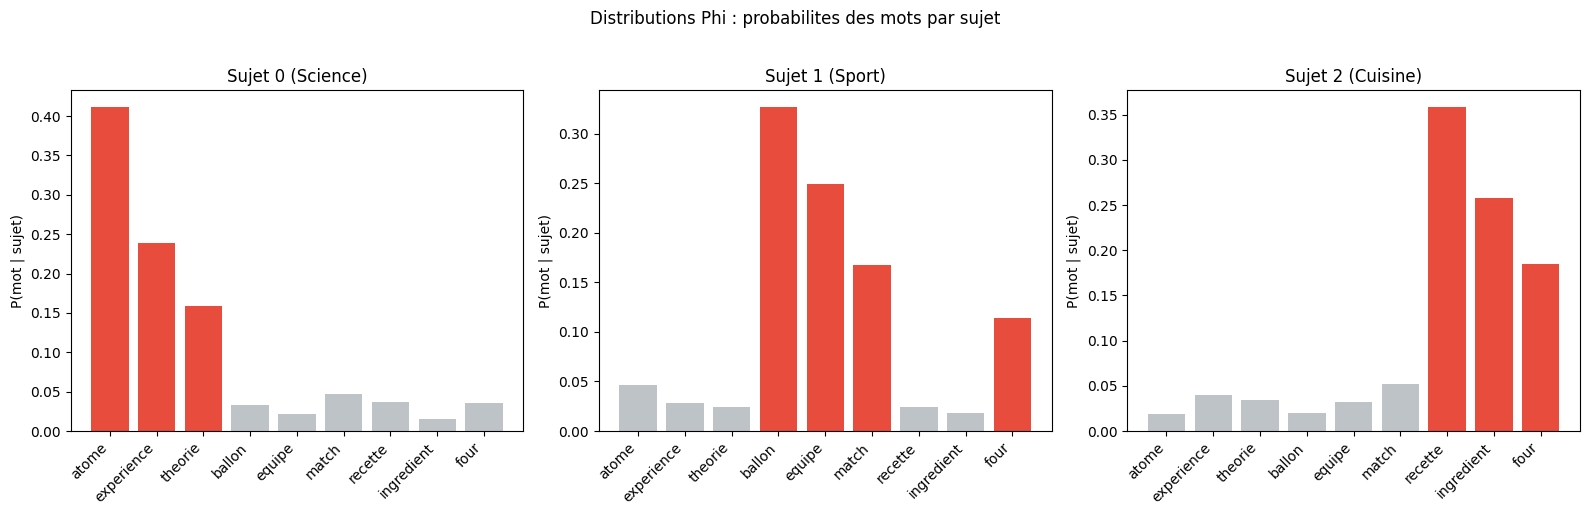

In [12]:
# Visualisation des distributions phi (mots par sujet)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for k in range(n_topics):
    colors = ['#e74c3c' if phi_asym[k, w] > 0.1 else '#bdc3c7'
              for w in range(n_vocab)]
    axes[k].bar(range(n_vocab), phi_asym[k], color=colors)
    axes[k].set_xticks(range(n_vocab))
    axes[k].set_xticklabels(vocab, rotation=45, ha='right')
    axes[k].set_title(f'Sujet {k} ({topic_labels[k]})')
    axes[k].set_ylabel('P(mot | sujet)')

plt.suptitle('Distributions Phi : probabilites des mots par sujet', y=1.02)
plt.tight_layout()
plt.show()

**Interprétation — la distribution Phi révèle la contamination inter-sujets.**

Le seuil rouge/gris de la visualisation (P(mot|sujet) > 0,1) isole les mots qui *définissent* chaque sujet :
les pics rouges sont nets — `atome` (0,41), `experience` (0,24), `theorie` (0,16) pour la Science ;
`ballon` (0,33), `equipe` (0,25) pour le Sport ; `recette` (0,36), `ingredient` (0,26) pour la Cuisine.
Cette concentration sur quelques mots dominants est précisément ce que le **prior de Dirichlet asymétrique**
a forcé (cellule précédente) : en pénalisant les distributions plates, il pousse chaque sujet vers un *pic*.

Mais la visualisation expose aussi ce que le tableau des 4 mots dominants masque : la **contamination**.

1. **`four` est rouge dans DEUX sujets** — Cuisine (0,185, l'« oven », sémantiquement correct) **et** Sport (0,114).
   Le modèle n'a pas pu attribuer ce mot à un seul sujet : il est polysémique (ou bruité), et LDA le
   « partage » entre les deux. C'est inhérent au modèle de sac de mots, qui ignore le contexte.
2. **`match` fuit dans les trois sujets** — rouge en Sport (0,169, son sens dominant « match sportif »),
   mais gris en Science (0,046) et Cuisine (0,053). Sa présence faible hors-Sport est l'empreinte du
   lissage du prior : aucun mot n'a une probabilité strictement nulle sous Dirichlet.

**Leçon** : les sujets LDA ne sont jamais *purs*. La lecture des distributions Phi complètes (et non
seulement des mots dominants) révèle les mots-frontières — ceux qui résistent à la classification unique.
Ces mots partagés sont aussi les premiers candidats à une **fusion de sujets** si l'on augmente le nombre
de documents ou diminue le nombre de sujets K.

### Analyse des proportions Theta

Après avoir visualise les distributions de mots par sujet (phi), on examine maintenant les proportions de sujets par document (theta). Chaque document est represente comme un melange des trois sujets, ce qui permet de caracteriser son contenu thematique.

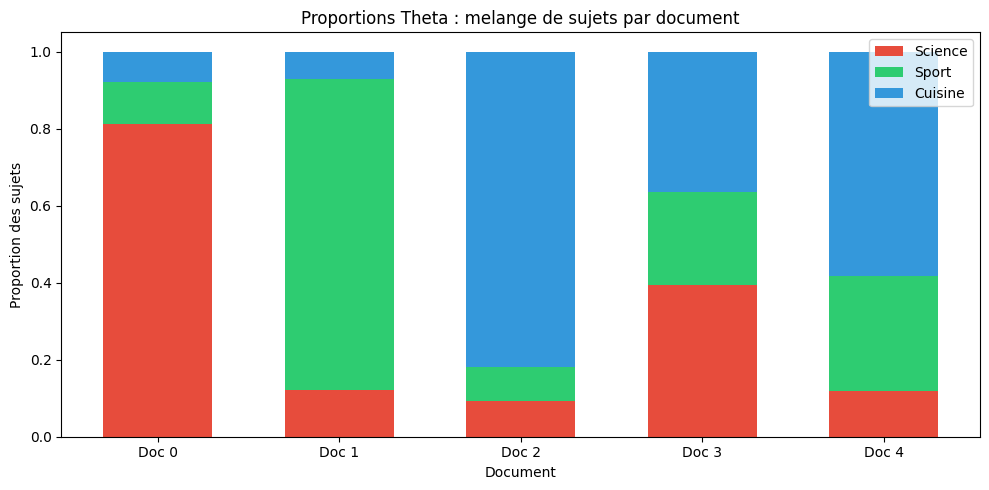

In [13]:
# Visualisation des proportions theta (sujets par document)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

x = np.arange(n_docs)
width = 0.6
bottom = np.zeros(n_docs)
colors = ['#e74c3c', '#2ecc71', '#3498db']

for k in range(n_topics):
    ax.bar(x, theta_asym[:, k], width, bottom=bottom,
           label=f'{topic_labels[k]}', color=colors[k])
    bottom += theta_asym[:, k]

ax.set_xlabel('Document')
ax.set_ylabel('Proportion des sujets')
ax.set_title('Proportions Theta : melange de sujets par document')
ax.set_xticks(x)
ax.set_xticklabels([f'Doc {d}' for d in range(n_docs)])
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 5. Analyse du Corpus

On peut verifier que le modèle a correctement identifie les sujets en comparant
les proportions estimees avec les vraies proportions.

In [14]:
# Comparaison vraies proportions vs estimees
print("Comparaison vraies proportions vs estimees :")
print(f"{'Doc':>6} {'Vraie theta':>30} {'Estimee theta':>30} {'Dominant':>10}")
print("-" * 80)

for d in range(n_docs):
    true_str = f"[{', '.join(f'{v:.2f}' for v in theta_true[d])}]"
    est_str = f"[{', '.join(f'{v:.2f}' for v in theta_asym[d])}]"
    true_dom = topic_labels[np.argmax(theta_true[d])]
    est_dom = topic_labels[np.argmax(theta_asym[d])]
    match = "OK" if true_dom == est_dom else "DIFF"
    print(f"{d:>6} {true_str:>30} {est_str:>30} {est_dom + ' (' + match + ')':>10}")

Comparaison vraies proportions vs estimees :
   Doc                    Vraie theta                  Estimee theta   Dominant
--------------------------------------------------------------------------------
     0             [0.80, 0.10, 0.10]             [0.81, 0.11, 0.08] Science (OK)
     1             [0.10, 0.80, 0.10]             [0.12, 0.81, 0.07] Sport (OK)
     2             [0.10, 0.10, 0.80]             [0.09, 0.09, 0.82] Cuisine (OK)
     3             [0.40, 0.40, 0.20]             [0.39, 0.24, 0.36] Science (OK)
     4             [0.20, 0.30, 0.50]             [0.12, 0.30, 0.58] Cuisine (OK)


## 5bis. Exemple resolu : selectionner le nombre de sujets (K)

Jusqu'ici, `K = 3` et les priors asymetriques `beta_asym` encodaient notre connaissance des trois sujets (Science, Sport, Cuisine). En pratique, on ne connait **ni K, ni les mots canoniques** des sujets : on doit choisir K en comparant des modeles ajustes sur les donnees seules.

Le protocole standard comporte trois mesures independantes, calculees sur les topics **effectivement appris** (jamais sur `phi_true`, jamais sur les etiquettes cachees) :

1. **Coherence UMass documentaire** (Mimno et al. 2011) : pour chaque sujet, les paires de ses mots dominants doivent co-apparaitre dans les memes documents. Valeurs proches de 0 = sujets interpretables.
2. **Redondance entre sujets** : similarite cosinus maximale entre paires de sujets appris. Un K trop grand fabrique des sujets quasi identiques.
3. **Log-vraisemblance predictive held-out** : chaque document est coupe en deux moities ; le modele est ajuste sur la premiere (49 mots), on evalue la probabilite moyenne des mots de la seconde (51 mots). Mesure la capacite predictive, pas seulement l'ajustement.

Chaque K fait donc l'objet de **deux ajustements separes** : un ajustement sur le **corpus complet** (100 mots) pour les mesures de qualite des sujets --- coherence et redondance s'estiment sur les sujets appris avec toutes les donnees, pratique standard des pipelines sklearn/gensim --- et un ajustement sur la **moitie d'apprentissage** pour la mesure predictive, qui exige par construction des mots tenus a l'ecart.

Deux precautions de rigueur :

- **Priors neutres** : `alpha = 0.5` (documents sparses) et `beta = 1` uniforme --- aucune information sur les sujets reels ne rentre dans le modele.
- **Alignement des permutations** : avec des priors symetriques, NUTS peut etiqueter les sujets differemment selon la chaine (*label switching*). Avant d'agreger, chaque tirage est re-ordonne par un tri canonique de ses lignes (ordre lexicographique des distributions de mots), applique conjointement a phi et theta.

On compare enfin le K selectionne au K reel (3) --- la verite terrain sert **uniquement** de controle final, jamais a construire les sujets.

In [15]:
# Protocole de selection de K : preparation split-half et coherence UMass

# Split-half deterministe par document : moitie 1 pour l'ajustement,
# moitie 2 pour l'evaluation predictive hors echantillon
docs_fit, docs_held = [], []
for doc in documents:
    milieu = len(doc) // 2
    docs_fit.append(doc[:milieu])
    docs_held.append(doc[milieu:])

bow_fit = np.zeros((n_docs, n_vocab), dtype=int)
bow_held = np.zeros((n_docs, n_vocab), dtype=int)
for d, doc in enumerate(docs_fit):
    for w in doc:
        bow_fit[d, w] += 1
for d, doc in enumerate(docs_held):
    for w in doc:
        bow_held[d, w] += 1
longueurs_fit = [len(doc) for doc in docs_fit]


def coherence_umass(phi_estime, docs, top_n=5):
    """Coherence UMass moyenne sur les sujets APPRIS.

    Pour chaque sujet k : les top_n mots dominants (selon phi_estime),
    somme sur les paires ordonnees de log((D(wi,wj)+1)/(D(wi)+1)),
    ou D compte les documents contenant le mot. Proche de 0 = coherent.
    """
    ensembles = [set(doc) for doc in docs]

    def freq_doc(w):
        return sum(1 for s in ensembles if w in s)

    def co_freq(w1, w2):
        return sum(1 for s in ensembles if w1 in s and w2 in s)

    scores_sujets = []
    for k in range(phi_estime.shape[0]):
        dominants = np.argsort(phi_estime[k])[::-1][:top_n]
        score = 0.0
        for i in range(len(dominants)):
            for j in range(len(dominants)):
                if i != j:
                    score += np.log((co_freq(dominants[i], dominants[j]) + 1)
                                    / (freq_doc(dominants[i]) + 1))
        scores_sujets.append(score)
    return float(np.mean(scores_sujets))


def phi_theta_alignes(trace):
    """Moyennes posterieures de phi et theta, permutations alignees.

    Avec des priors symetriques, chaque chaine peut etiqueter les sujets
    dans un ordre different (label switching) : la moyenne brute melangerait
    les permutations. On re-ordonne chaque tirage par tri lexicographique
    canonique des lignes de phi, permutation appliquee aussi a theta.
    """
    phi_tirs = trace.posterior['phi'].stack(
        echant=('chain', 'draw')).transpose('echant', 'phi_dim_0', 'phi_dim_1').values
    theta_tirs = trace.posterior['theta'].stack(
        echant=('chain', 'draw')).transpose('echant', 'theta_dim_0', 'theta_dim_1').values
    n_tirs, _, n_v = phi_tirs.shape
    phi_alignes = np.empty_like(phi_tirs)
    theta_alignes = np.empty_like(theta_tirs)
    for t in range(n_tirs):
        ordre = np.lexsort([phi_tirs[t, :, w] for w in range(n_v)])
        phi_alignes[t] = phi_tirs[t][ordre]
        theta_alignes[t] = theta_tirs[t][:, ordre]
    return phi_alignes.mean(axis=0), theta_alignes.mean(axis=0)


print(f"Split-half : {sum(longueurs_fit)} mots ajustement / {bow_held.sum()} mots held-out")
print("Coherence UMass et alignement des permutations prets.")

Split-half : 49 mots ajustement / 51 mots held-out
Coherence UMass et alignement des permutations prets.


In [16]:
# Ajustement reel des LDA concurrentes : K = 2..6, priors neutres, moteur NUTS
# Deux ajustements par K : corpus complet (qualite des sujets) + moitie 1 (predictif)
grille_K = [2, 3, 4, 5, 6]
resultats_K = []
phi_par_K = {}

for K in grille_K:
    # Ajustement A : corpus complet -> sujets appris pour coherence/redondance
    with pm.Model() as modele_plein:
        phi_A = pm.Dirichlet('phi', a=np.ones((K, n_vocab)), shape=(K, n_vocab))
        theta_A = pm.Dirichlet('theta', a=np.ones(K) * 0.5, shape=(n_docs, K))
        pm.Multinomial('obs', n=doc_lengths, p=pt.dot(theta_A, phi_A),
                       observed=bow_matrix)
        trace_plein = pm.sample(1500, random_seed=42, return_inferencedata=True,
                                progressbar=False)
    phi_plein, _ = phi_theta_alignes(trace_plein)
    phi_par_K[K] = phi_plein

    # Ajustement B : moitie 1 -> thetas pour la mesure predictive held-out
    with pm.Model() as modele_demi:
        phi_B = pm.Dirichlet('phi', a=np.ones((K, n_vocab)), shape=(K, n_vocab))
        theta_B = pm.Dirichlet('theta', a=np.ones(K) * 0.5, shape=(n_docs, K))
        pm.Multinomial('obs', n=longueurs_fit, p=pt.dot(theta_B, phi_B),
                       observed=bow_fit)
        trace_demi = pm.sample(1500, random_seed=42, return_inferencedata=True,
                               progressbar=False)
    phi_demi, theta_demi = phi_theta_alignes(trace_demi)

    # Mesure 1 : coherence UMass sur les sujets appris (corpus complet)
    coherence = coherence_umass(phi_plein, documents, top_n=5)

    # Mesure 2 : redondance = similarite cosinus max entre paires de sujets
    normalises = phi_plein / np.linalg.norm(phi_plein, axis=1, keepdims=True)
    similarites = normalises @ normalises.T
    np.fill_diagonal(similarites, 0.0)
    redondance = float(similarites.max()) if K > 1 else 0.0

    # Mesure 3 : log-probabilite moyenne par mot held-out (ajustement B uniquement)
    probs_doc = theta_demi @ phi_demi
    log_ll = 0.0
    n_mots_held = 0
    for d in range(n_docs):
        for w, compte in enumerate(bow_held[d]):
            if compte > 0:
                log_ll += compte * np.log(probs_doc[d, w] + 1e-12)
                n_mots_held += compte
    log_ll_par_mot = log_ll / n_mots_held

    resultats_K.append({'K': K, 'coherence': coherence,
                        'redondance': redondance, 'heldout': log_ll_par_mot})
    print(f"K={K} : coherence UMass={coherence:.2f}, redondance={redondance:.3f}, "
          f"log-prob/mot held-out={log_ll_par_mot:.3f}")

print("\nSynthese de la selection de K :")
print(f"{'K':>3} {'UMass':>8} {'redondance':>11} {'held-out/mot':>13}")
print("-" * 40)
for r in resultats_K:
    print(f"{r['K']:>3} {r['coherence']:>8.2f} {r['redondance']:>11.3f} "
          f"{r['heldout']:>13.3f}")

# Mots dominants par sujet pour chaque K (les sujets APPRIS)
for K in grille_K:
    dominants = np.argsort(phi_par_K[K], axis=1)[:, ::-1][:, :4]
    print(f"\nK={K} : " + " | ".join(
        f"sujet {k} = {', '.join(vocab[w] for w in dominants[k])}"
        for k in range(K)))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [phi, theta]


Sampling 4 chains for 1_000 tune and 1_500 draw iterations (4_000 + 6_000 draws total) took 15 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [phi, theta]


Sampling 4 chains for 1_000 tune and 1_500 draw iterations (4_000 + 6_000 draws total) took 13 seconds.


K=6 : coherence UMass=-4.10, redondance=0.995, log-prob/mot held-out=-2.193

Synthese de la selection de K :
  K    UMass  redondance  held-out/mot
----------------------------------------
  2    -4.19       0.911        -2.173
  3    -3.78       0.941        -2.184
  4    -4.05       0.975        -2.188
  5    -4.06       0.990        -2.190
  6    -4.10       0.995        -2.193

K=2 : sujet 0 = atome, recette, experience, ballon | sujet 1 = recette, four, ingredient, atome

K=3 : sujet 0 = atome, experience, recette, theorie | sujet 1 = recette, ingredient, atome, four | sujet 2 = four, ballon, recette, equipe

K=4 : sujet 0 = atome, recette, experience, ballon | sujet 1 = atome, recette, ingredient, experience | sujet 2 = recette, four, ingredient, atome | sujet 3 = four, ballon, recette, equipe

K=5 : sujet 0 = atome, recette, experience, ingredient | sujet 1 = atome, recette, experience, ingredient | sujet 2 = recette, atome, ingredient, four | sujet 3 = four, recette, ballon, in

### Interpretation : des metriques qui divergent

Aucun K ne gagne sur les trois mesures --- chaque metrique repond a une question differente :

| Mesure | Gagnant | Lecture |
|--------|---------|---------|
| Coherence UMass | **K=3** (-3.78) | Le seul maximum local de la grille --- et le K generateur du corpus |
| Held-out | **K=2** (-2.173) | Decroissance monotone ; ecart de 0.011 nat/mot contre K=3 : dans le bruit pour 51 mots |
| Redondance | penalise K grand | Croit de 0.911 a 0.995 : chaque sujet supplementaire est de plus en plus similaire aux existants |

Quatre enseignements :

1. **La coherence designe le bon K ici.** K=3 est le seul pic de coherence, et les top-mots montrent une structure reconnaissable : sujet 0 = atome, experience, theorie (Science), sujet 1 = recette, ingredient, four (Cuisine), sujet 2 = four, ballon, recette, equipe (Sport partiellement colle a la Cuisine).

2. **La mesure predictive, elle, prefere K=2 et decroit des K=3.** Avec seulement 49 mots d'apprentissage, chaque sujet supplementaire dilue les comptes par document : le modele sous-determine perd immediatement en prevision. Cette divergence coherence-vs-prevision est la lecon centrale du protocole : un critere unique n'est pas une selection.

3. **Les sujets appris restent plus flous que ceux de la section 4** (priors informes). NUTS echantillonne le posterieur complet ; malgre l'alignement canonique des permutations, les modes multiples laissent des traces (le mot « recette », le plus frequent du corpus, residue dans plusieurs sujets). Le jumeau Infer.NET, avec VMP et une initialisation jitteree, s'engage dans un seul mode et rend des sujets plus tranches --- un contraste honnete entre paradigmes d'inference, pas une difference de qualite intrinseque.

4. **Verdict honnete** : aucune dominance nette. La selection combine le pic de coherence (K=3), la redondance qui exclut les grands K, et la lecture des top-mots ; la verite terrain (3 sujets) confirme le choix sans avoir servi a le construire.

Ces sujets viennent de l'inference (priors neutres `alpha=0.5`, `beta=1`, alignement des permutations) : ni `phi_true`, ni `beta_asym` n'ont guide l'apprentissage.

## 6. Extensions du Topic Modeling

LDA est le modèle de base. Plusieurs extensions existent :

| Modèle | Description | Cas d'usage |
|--------|-------------|------------|
| **HDP** (Hierarchical DP) | Nombre de sujets appris automatiquement | Quand K est inconnu |
| **CTM** (Correlated Topic Model) | Sujets correlés (logistique-normale) | Sujets semantiquement proches |
| **DTM** (Dynamic Topic Model) | Sujets evoluent dans le temps | Corpus temporels |
| **sLDA** (Supervised LDA) | Combine topics + labels de classe | Classification supervisee |

En pratique, on utilise souvent `sklearn.decomposition.LatentDirichletAllocation`
ou `gensim` pour des corpus reels, car l'implementation est plus rapide que
l'inference MCMC complete.

In [17]:
# Comparaison rapide avec sklearn LDA (pour reference)
from sklearn.decomposition import LatentDirichletAllocation

lda_sklearn = LatentDirichletAllocation(n_components=3, random_state=42,
                                         max_iter=50)
lda_sklearn.fit(bow_matrix)

phi_sklearn = lda_sklearn.components_ / lda_sklearn.components_.sum(axis=1, keepdims=True)
theta_sklearn = lda_sklearn.transform(bow_matrix)

print("sklearn LDA (pour reference, beaucoup plus rapide) :")
for k in range(n_topics):
    top_words = np.argsort(phi_sklearn[k])[::-1][:4]
    top_str = ', '.join([f"{vocab[w]} ({phi_sklearn[k, w]:.3f})" for w in top_words])
    print(f"  Sujet {k} : {top_str}")

sklearn LDA (pour reference, beaucoup plus rapide) :
  Sujet 0 : atome (0.282), ballon (0.145), experience (0.139), equipe (0.121)
  Sujet 1 : recette (0.214), four (0.174), ballon (0.134), ingredient (0.132)
  Sujet 2 : recette (0.316), ingredient (0.278), four (0.117), match (0.100)


## 7. Exercice : Corpus Etendu

Créez un corpus avec 4 sujets (Sport, Tech, Cuisine, Voyage) et 12 mots.
Testez LDA avec priors asymetriques et verifiez que les sujets sont bien identifies.

**Indices** :
- Définir 12 mots (3 par sujet) : `vocab2 = ['ballon', 'équipe', 'match', 'code', 'algorithme', 'données', ...]`
- Construire `beta_asym2` avec 4 lignes (sujets) et 12 colonnes (mots)
- Generer 8 documents avec des proportions theta variees
- Estimer avec le modèle PyMC et verifier les résultats

In [18]:
# TODO etudiant : implementer le corpus etendu a 4 sujets
# Resultat attendu : 4 sujets bien differencies (Sport, Tech, Cuisine, Voyage)

print("Exercice a completer")

Exercice a completer


---

**Retour au sommaire** : [Index Probas](../README.md)

## Conclusion

Les modèles de sujets (Topic Models) comme LDA decomposent un corpus de documents en thèmes latents, chaque document etant un melange de topics.

### Points cles
- LDA suppose chaque document = melange de K topics, chaque topic = distribution sur le vocabulaire
- Le nombre de topics K peut etre selectionne par coherence ou critères predictifs
- L'inference variationnelle et MCMC sont les deux approches principales pour estimer les topics

## 8. Resume : Infer.NET vs PyMC pour le Topic Modeling

| Aspect | Infer.NET | PyMC |
|--------|-----------|------|
| Algorithme | VMP (Variational Message Passing) | NUTS (MCMC) |
| Rupture de symetrie | Priors asymetriques sur phi | Pareil |
| Variables discretes | Natif (`Variable.Discrete`) | `pm.Categorical` + `CategoricalGibbsMetropolis` |
| Performance | Rapide (VMP converge en ~20 itérations) | Lent (MCMC necessite des milliers d'echantillons) |
| Alternative pratique | N/A | `sklearn.decomposition.LatentDirichletAllocation` |

**Lecons** :
1. La **rupture de symetrie** est essentielle en topic modeling, que ce soit en Infer.NET ou en PyMC
2. Les priors asymetriques sur `phi` sont la méthode la plus efficace pour briser la symetrie
3. Pour des corpus reels, `sklearn` ou `gensim` sont preferes pour la performance
4. PyMC reste utile pour comprendre le modèle generatif et explorer des variantes

---

**Retour au sommaire** : [Index Probas](../README.md)

## Références

| Référence | Section / Numéro | Lien au notebook |
|-----------|------------------|-------------------|
| Blei, Ng & Jordan (2003), *JMLR* 3:993-1022, "Latent Dirichlet Allocation" | — | Article fondateur de LDA (modèle génératif documents-topics-mots) |
| Pritchard, Stephens & Donnelly (2000), *Genetics* 155:945-959 | — | Version ancestrale (LDA-like) avec priors Pritchard-Stephens-Donnelly |
| Heinrich (2005) "Parameter estimation for text analysis" | Technical report | Tutorial LDA + Gibbs sampling + variational |
| MBML "Latent Dirichlet Allocation" (sub-page) | — | Portage MBML-IDIAP du modèle LDA — version courte canonique suivant Blei 2003 |

> **Note pedagogique** : PyMC utilise NUTS (No-U-Turn Sampler, Hoffman & Gelman 2014) pour explorer le posterior LDA. Pour comparer NUTS ↔ VMP d'Infer.NET, voir la note technique de Heinrich (2005) et *Probabilistic Machine Learning* (Murphy 2023), §10.3.7 (Variational Message Passing) et §12.5 (Markov chain Monte Carlo).